# Module 6 - working with modules
---------------------------------------------------

<div class="alert alert-block alert-info">
<b>Note:</b> this notebook contains <b>Additional Material</b> sections (in blue boxes, like this one) that will be skipped during the class due to time constraints. If you are going through this notebook on your own, feel free to
read these sections or skip them depending on your interest.
</div>

### Table of Content <a id='toc'></a>

<br>

[**Introduction**](#1) 

[**Importing modules**](#2)  
&nbsp;&nbsp;&nbsp;&nbsp;[1. Importing the module name, without adding all of its content to your namespace](#2.1)  
&nbsp;&nbsp;&nbsp;&nbsp;[2. Importing the module name as an alias](#2.2)  
&nbsp;&nbsp;&nbsp;&nbsp;[3. Importing specific objects from a module](#2.3)  
&nbsp;&nbsp;&nbsp;&nbsp;[Micro-Exercise 1](#2.4)  

[**Importing your own module**](#3)


[**Some python built-in modules of interest...**](#4)

[**Install modules needed for the upcoming notebooks**](#5)

[**Additional Material**](#7)  
&nbsp;&nbsp;&nbsp;&nbsp;[Installing python modules/packages](#7.1)  
&nbsp;&nbsp;&nbsp;&nbsp;[Python native module example: `os`](#7.2)  
&nbsp;&nbsp;&nbsp;&nbsp;[Python native module example: `time`](#7.3)  
&nbsp;&nbsp;&nbsp;&nbsp;[The `%timeit` "magic" function (only works in Jupyter Notebooks)](#7.4)  
&nbsp;&nbsp;&nbsp;&nbsp;[Building your own modules](#7.5)   
&nbsp;&nbsp;&nbsp;&nbsp;[Additional exercises 6.1-6.4](#7.6)  

<br>
<br>

## Introduction <a id='1'></a>
-------------------

Good news: almost everything you will want to do in Python has already been implemented by someone else. 
Many workflows have been developed into **modules** which can be **imported** into your Python session.

There are 2 categories of modules:
* **Built-in modules**: modules that come bundled with the basic Python installation and therefore do not need to be installed.
* **External modules**: modules that need to be specifically installed. The large majority of modules fall in this category. Most
  of them are hosted on <a href="https://pypi.org">PyPI.org</a> (the Python Package Index).

The <a href=https://www.anaconda.com>**Anaconda distribution**</a> - which in principle is the way you installed python for this course - is a project that bundles the base python distribution with a number of popular external packages/modules for data science, such as `numpy`, `scipy`, or `pandas`.

Additional packages with modules can be installed to your (environment-specific) library using the <a href="https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-pkgs.html">`conda package manager`</a> or <a href="https://pypi.org">`pip`</a>, both of which are shipped with Anaconda. 

> ⚠️ **It is not advisable to mix installations via `conda` and via `pip` within a same Conda environment.**  
  So it's best if you stick to using conda for the time being.

<br>

**Official python documentation**, including python native modules: https://docs.python.org  

<br>

<br>

<div class="alert alert-block alert-info">

#### Additional material: package vs. module, what's the difference?

Technically:
* A **module** is a simply a single `.py` file.
* A **package** is a group of python modules stored in a directory that contains a `__init__.py` file
  (this file is read when the module is loaded).

As we will see in this notebook, both packages and modules are loaded with the same command, so in practice the terms package and module are often used interchangeably.

<br>

**Examples:**  
* *Note:* the file location is here shown for a standard installation on Linux. It will likely be different on your machine.

* The **`os`** module (interactions with the file system) is composed of a single file.

    ```sh
    /usr/lib/python3.10
                 └── os.py
    ```
    <br>

* The **`json`** module (reading from and writing to JSON format) is a package containing multiple module files.
  (note the `__init__.py` file at the root of the `json` directory).

    ```sh
    /usr/lib/python3.10/json
                         ├── __init__.py
                         ├── decoder.py
                         ├── encoder.py
                         └── tool.py
    ```

</div>

<br>
<br>

[Back to ToC](#toc)


## Importing modules <a id='2'></a>
---------------------------

There are 3 main ways to **import modules** into your code, which we will demonstrate here.


### 1. Importing the module name, without adding all of its content to your namespace <a id='2.1'></a>
* This is the **simplest, and most frequently used**, way to import a module.
* Any object of the module (e.g. a function) must be called using the syntax: **`modulename.object`**
  as the name of the object is not directly made available in the namespace - only the name of the module is.  
  This is actually a good thing because:
    * It **avoids adding a lot of names to the namespace** (most of which we probably don't need).
    * It gives an **indication of where the function/class/object is taken from**.

In [2]:
import os

print("Your operating system is:", os.name)
print("The current work dir is :", os.getcwd())

Your operating system is: nt
The current work dir is : C:\Git\first-steps-with-python-training\notebooks


In [3]:
import statistics

statistics.mean(range(101))

50

<br>

* ⚠️ **Warning:** trying to call a function directly - in this case `mean()` - without prefixing it with its module name raises a **`NameError`**, because the name of individual functions are not imported into your Python session's namespace.

In [ ]:
import statistics

mean(range(101))   # -> Raises a NameError !

<br>

### 2. Importing the module name as an alias <a id='2.2'></a>

This is essentially the same as the first solution above, with the only difference that the module name is given an **alias**.  
This is generally used for modules with long names.

In [ ]:
import statistics as stats

stats.mean(range(11))

* ✨ **Tip:** many popular modules are, by convention, always imported under the same alias.

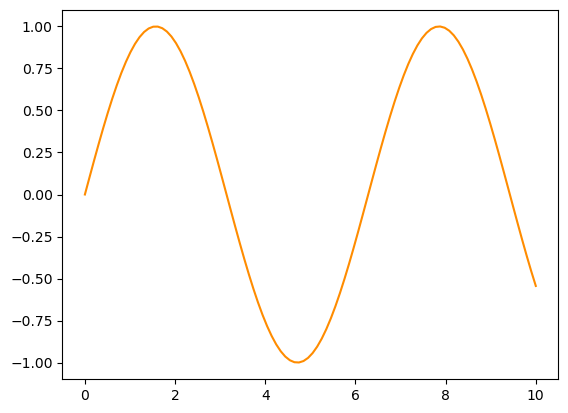

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.plot(np.linspace(0, 10, 100), [np.sin(x) for x in np.linspace(0, 10, 100)], color='darkorange')
plt.show()

<br>

### 3. Importing specific objects from a module <a id='2.3'></a>

This is useful when you only need a limited number of objects from a module.

In this example, we only import the function `getcwd()` and the attribute `name` from the **`os` module**:

In [ ]:
from os import getcwd, name

print("The type of the operating system running this Jupyter instance is:\n ->", name)
print("The current working directory is:\n ->", getcwd())

<br>

At first, this third method may appear nicer as it leads to shorter code. However, it often **hampers code readability**: you now have a variable called `name` but it is not immediately obvious from where it comes! Is a variable you created yourself? or was it imported from somewhere, and if so, from which module?

Therefore **this third method should be used with parsimony**: only in specific cases, e.g. when you are using a specific function from a module many times in your code and don't want to each time prefix it with the name of the module to call it.

<br>

#### Importing all objects from a module - a bad idea 💥

Finally, it is also possible to import all the object from a module at once with **`from module import *`**.  
While this might again look convenient, it is **bad practice**, and we only show it here so you **know to avoid it** when you see it!

Here is why importing all objects with **`from ... import *`** is bad practice:
  1. **Unnecessarily pollutes your namespace** (i.e. creates many new names that you will not use).
  2. **Can lead to unpredictable results**, since the content of a module might change over time and
     you are simply importing it all without any check of what it actually is.


In [ ]:
# Something to avoid !
from pandas import *

# Display objects in namespace with the "%whos" jupyter command.
%whos

In [ ]:
import pandas

%whos


<br>

<div class="alert alert-block alert-success">

### Micro Exercise 1 <a id='2.4'></a>
* Compute the base 10 logarithm of the factorial of 101. In mathematical notation: `log10(101!)`.  
  🎯 **Hint:** have a look at the [math module](https://docs.python.org/3/library/math.html)
    
</div>

In [15]:
import math as mt
mt.log10(mt.factorial(101))

159.97432502849844

In [16]:
from math import log10, factorial
log10(factorial(101))

159.97432502849844

<br>
<br>

[Back to ToC](#toc)

## Importing your own module <a id='3'></a>
--------------------------------------

Sometimes it can be useful to import your **own module**. This is typically so that you can:
* **Re-use elements**, e.g. a function you wrote earlier.
* **Organize your code** into multiple files, e.g. your main workflow in one file, and functions 
  grouped by category in different files (modules).

Importing your own module is done exactly like with built-in and external modules.

<br>

**Example:** import a module `my_own_module` from the file `my_own_module.py`.
* 🦉 *Note:* The following example works because `my_own_module.py` is located in the current working directory.  
* Modules files must be stored at specific locations to be importable.

In [18]:
import my_own_module

help(my_own_module)

Help on module my_own_module:

NAME
    my_own_module

DESCRIPTION
    This is a test module for demonstration purpose. This part of the module
    is called the 'module docstring' and can be used to add a description of
    the module.

FUNCTIONS
    greeting(name='')
        Prints a greeting addressed to the person specified
        person passed as name argument.

        name:
            name of the person to greet.

DATA
    DEFAULT_USER = 'Alice'

FILE
    c:\git\first-steps-with-python-training\notebooks\my_own_module.py




In [19]:
import my_own_module

my_own_module.greeting()
my_own_module.greeting(my_own_module.DEFAULT_USER)

Hello, stranger.
Hello, Alice


<br>

* **Importing individual objects** from the module.

In [ ]:
from my_own_module import greeting, DEFAULT_USER

greeting(name="Bob")
greeting(DEFAULT_USER)

<br>

* Importing the module as an **alias**.

In [ ]:
import my_own_module as mom

mom.greeting(name="James")


<br>

[Back to ToC](#toc)

# Some python built-in modules of interest... <a id='4'></a>

There are [many modules](https://docs.python.org/3/py-modindex.html) integrated to the basic python distribution. Here are a few of them:
* **`os`**: interact with the computer's system and files - see **Additional Material** section below.
* **`time`**: access and measure time - see **Additional Material** section below.
* **`argparse`**: to generate command line interfaces (CLI) for your scripts.
* **`random`**: to generate random numbers with various common distributions. But **`numpy`** is better and do more than rdm-generations.
* **`collections`**: contains some useful container classes.
* **`itertools`**: useful iterators. Your go-to for combinatorics (eg. permutations, combinations, ...).

<br>
<br>
<br>

[Back to ToC](#toc)

# Install modules needed for the upcoming notebooks <a id='5'></a>
----------------------------------------------------------------------------------

In the coming lessons, we will introduce you to several well known Python libraries that are particularly useful when doing bioinformatics or (biological) data-analysis.

* **`matplotlib`**: creating graphics and images with Python.
* **`pandas`**: efficient and easy data tables (DataFrame) reading, writing and manipulation.
  Allows to manipulate tabular data in a similar way as in R.
* **`biopython`**: for manipulating biological sequences, database records and phylogenetic trees.
* **`numpy and scipy`**: efficient matrix manipulation, and statistical functions.

Use the following code to ensure every library is properly installed :


In [ ]:
# Note: you may comment-out any library you are not interested in.

import Bio            # biopython: bioinformatics in python.
import matplotlib     # Create high-quality plots.
import numpy          # Powerful array structure for fast numerical computation.
import scipy          # Scientific computing package, with linear algebra and statistical tests.
import pandas         # Powerful DataFrame structure that mimics R dataframe. A must for data analysis.
print('All libraries imported successfully')

If any of these fail, install them by typing the relevant command (see below) in your **terminal (Linux and MacOS)**, or the **conda console (Windows)** - not in the Jupyter Notebook:

* **`biopython`**: type `conda install -c anaconda biopython`
* **`matplotlib`**: follow instructions from [here](https://github.com/conda-forge/matplotlib-feedstock#installing-matplotlib-suite)
* **`pandas`**: type `conda install pandas`
* **`scipy`**: type `conda install scipy` 
* **`numpy`**: type `conda install numpy`

<br>
<br>
<br>

[Back to ToC](#toc)

<div class="alert alert-block alert-info">

# Additional Material <a id='7'></a>
-----------------------------

</div>

<br>

## Installing python modules/packages <a id='7.1'></a>

There are two package managers associated with Python:
* **conda** - bundled with [Anaconda](https://www.anaconda.com) or
  [miniconda](https://docs.conda.io/en/latest/miniconda.html).
* **pip** - the [package installer for python](https://pip.pypa.io/en/stable/index.html).

Generally they play nicely together, and package installation can be done with either of them. Nevertheless, the pseudo-consensus on best practices seems to be that, if you are using a conda virtual environment, then you should try to install packages with conda as much as possible (and only use `pip` in cases where a package is unavailable in the conda repos).

The syntax to install a package with `conda` or `pip` is the following:

    conda install mypkg
    pip install --user mypkg

### The Conda package manager

Conda is an open-source **package and environment management system** that runs on Windows, macOS, and Linux.  
It has 2 main functionalities:
* Allows to easily install python packages (and other software too).
* Allows to create so called **virtual-environments** that are isolated from each other and your main
  operating system. This allows you to have a specific (and different) set of packages installed in
  each environment. For instance, you could have one environment with Python 3.10 and a specific set of
  modules, and another environment with Python 3.8 and a different set of modules.
  
The following section will give a very brief primer on using `conda`. For more info, please have a look at https://docs.conda.io.

<br>

#### Managing Conda environments

We show here the command line interface with conda. 
If you prefer to use the anaconda navigator graphical interface, you can refer to their [environment](https://docs.anaconda.com/free/navigator/tutorials/manage-environments/) and [package](https://docs.anaconda.com/free/navigator/tutorials/manage-packages/) management tutorials


Creating an environment with a specific version of Python:

    conda create --name myenv python=2.7.11
    
To avoid any potential conflicts between modules, it is good practice to specify all the additional modules you will need at the time you create your environment. *eg:*

    conda create --name myenv python=3.4 numpy scipy matplotlib pandas scikit-learn

List your existing conda environments:

    conda info --envs
    
List the packages installed installed in a given environment (`myenv`):

    conda list --name myenv
    
Activating and deactivating an environment (Windows):

    # from the Anaconda Prompt
    activate myenv
    deactivate
    
Activating and deactivating an environment (Linux / MacOS):

    conda activate myenv
    conda deactivate



<br>
<br>

[Back to ToC](#toc)

## Python native module example: `os` <a id='7.2'></a>
--------------------------------------

The <a href="https://docs.python.org/3/library/os.html">`os`</a> module is a **native python module** (meaning it comes installed with base python) **designed to manage interactions with the operating system**.  
It greatly enhances code portability, as it allows you to run the same code on different platforms (Linux, Windows, MacOS).

Here we give an overview of a few useful functions from `os`, but there are plenty more.


**Get** and **set working directory** with:
* **`os.getcwd()`:** return the current working directory.
* **`os.chdir(path)`:** set the working directory to `path`.

<br>

**Examples:** changing the current working directory.

In [ ]:
import os

current_wd = os.getcwd()
print('Current working dir:', current_wd, '\n')

In [ ]:
os.chdir('../slides')
print('Working dir changed to:', os.getcwd(), '\n')

In [ ]:
os.chdir(current_wd)
print('Working dir is now again:', os.getcwd(), '\n')

<br>

#### Manipulate files and directories:
* `os.mkdir(path)` - creates a new directory non-recursively. To create directories recursively use `os.makedirs(path)`.
* `os.rmdir(path)` - deletes `path` if it is an empty directory.
* `os.remove(path)` - deletes the file `path` (does not delete directories, even if empty).
* `os.listdir(path)` - lists the content (files and directories) of `path`.

#### Manipulate paths:
* `os.path.basename(path)` - returns the **basename** of a path, i.e. the last element (file or dir) of a path.
* `os.path.dirname(path)` - returns the parent directory of the last element of a path.
* `os.path.isfile(path)` - returns `True` if `path` is an existing regular file (note: follows symlinks
  -> returns `True` for symlinks).
* `os.path.isdir(path)` - returns `True` if `path` is an existing directory.
* `os.path.join(path1, path2, ...)` - returns a new path by appending all paths passed as arguments one after the other.

<br>

#### Examples:
* Get the **parent directory** of a file or directory:

In [ ]:
current_wd = os.getcwd()
print("Current working directory:", current_wd)

parent_dir = os.path.dirname(current_wd)
print("Its parent directory is  :", parent_dir)

<br>

* List **content of a directory**:

In [ ]:
print(os.listdir(current_wd))

<br>

* Test if a path **is a file or directory**:

In [ ]:
path_1 = os.path.join(current_wd, "00_jupyter_setup.ipynb")
path_2 = os.path.join(current_wd, "data")
path_3 = os.path.join(current_wd, "exam_solution.py")

for file_path in (path_1, path_2, path_3):
    
    print("Is '", os.path.basename(file_path), "' a file?  ", sep="", end="")
    
    if os.path.isfile(file_path):
        print("Yes, it is!")
    elif os.path.isdir(file_path):
        print("No, it is a directory.")
    else:
        print("Looks like this file does not exist!")

<br>

* Example of a function that lists the content of a directory.
  Can be used as **inspiration for exercise 6.1**

In [ ]:
import os

def list_files_from_dir(path, show_hidden=False):
    """Prints files and directories found at a given path.
    Ignores files part of the ignored list.
    """
    
    # Print name of input directory:
    input_summary = "Content of directory: " + os.path.basename(path)
    if show_hidden:
        input_summary += " (including hidden files)"
    print(input_summary)
    
    # Print files in the directory.
    if not os.listdir(path):
        print(" - directory is empty")
        
    for f in os.listdir(path):
        if not f.startswith(".") or show_hidden:
            print(" -", f)
    
    # This simply adds an empty line at the end of the output.                        
    print("\n", end="")
    
    
# List files in the parent of the current working directory.
parent_dir = os.path.dirname(os.getcwd())
list_files_from_dir(parent_dir)
list_files_from_dir(parent_dir, show_hidden=True)

files_orig = os.listdir(path='.')


# Create a new directory:
new_dir = os.path.join(parent_dir, 'tmp_dir')
os.mkdir(new_dir)
list_files_from_dir(new_dir)
os.rmdir(new_dir)                # This removes the newly created directory


<br>
<br>
<br>

[Back to ToC](#toc)


## Python native module example: `time` <a id='7.3'></a>
---------------------------------------

The <a href="https://docs.python.org/3/library/time.html">`time`</a> module is designed to measure and format time. It is very useful to monitor code execution times, e.g. when doing optimization.  
Here are a few interesting functions from the `time` module:
* `time.time()` - returns the **time in seconds since the epoch** as a floating point number.
  The epoch is the point from when the time starts (for your computer!), and is platform dependent.
  For Unix, the epoch is January 1, 1970, 00:00:00 (UTC - Coordinated Universal Time - the same as GMT).
* `time.gmtime()` - transforms the number of seconds given by `time.time()` into a human readable 
  UTC **`struct_time`** object.
* `time.localtime()` - same as `.gmtime()` but transforms to local time.
* `time.asctime(struct_time)` - formats `struct_time` objects into a nice string.

In [ ]:
import time

current_time = time.time()
print("The current time is:", current_time)
print("Oh, sorry, I forgot you are a mere human... \nLet me convert that for you:", 
      time.asctime(time.localtime(current_time)), '\n')

Let's have a look at `time_struct` object.

In [ ]:
current_time_struct = time.localtime(current_time) 
print("This is the structure returned by 'localtime()' and 'gmtime()':\n", current_time_struct, "\n")

Let's look at what the epoch is for your system:

In [ ]:
print("The current Epoch is:", time.asctime(time.gmtime(0)))
print("The current Epoch is:", time.asctime(time.localtime(0)), "(in local time)")

<br>

**Example:** use the `time` module to measure the execution time of some code.

In [ ]:
# Implementation version 1 of the reverse complement function: uses if... else...
def reverse_complement_v1(seq):
    """Returns the reverse complement of a DNA sequence"""
    
    reversed_seq = "" 
    for nucleotide in seq:
        if nucleotide == 'A':
            reversed_seq += 'T'
        elif nucleotide == 'T':
            reversed_seq += 'A'
        elif nucleotide == 'G':
            reversed_seq += 'C'
        elif nucleotide == 'C':
            reversed_seq += 'G'
        else:
            pass
    
    return reversed_seq[::-1]


# Implementation version 2 of the reverse complement function: uses a dictionary.
def reverse_complement_v2(seq):
    """Returns the reverse complement of a DNA sequence"""
    
    nucleotide_complements = {'A':'T', 'T':'A', 'C':'G', 'G':'C'}
    reversed_complement = ""
    for nucleotide in seq[::-1]:
        reversed_complement += nucleotide_complements[nucleotide]
    
    return reversed_complement


Let's benchmark our 2 implementations:

To compute the time needed to run a function, we proceed as follow:
1. Store the current time at start of execution in the "start_time" variable.
2. Run our function.
3. Compute the runtime by comparing the current time before and after the function is run.

In [ ]:
import time 

test_sequence = "ATAGAGCGATCGATCCCTAG"

start_time = time.time()                          
rev_comp_v1 = reverse_complement_v1(test_sequence)
time_v1 = time.time() - start_time
print(time_v1)

start_time = time.time()
rev_comp_v2 = reverse_complement_v2(test_sequence)
time_v2 = time.time() - start_time
print(time_v2)

In [ ]:
def time_it(function, argument):
    """Compute runtime of a function. NB: Only works with function that have a single argument"""
    start_time = time.time()
    function(argument)
    return time.time() - start_time


test_sequence_patterns = ["ATAGAGCGATCGATCCCTAG",
                          "AAAAAAAAAAAAAAAAAAAA",
                          "CCCCCCCCCCCCCCCCCCCC"]

for sequence_pattern in test_sequence_patterns:
    print("Starting benchmark for pattern:", sequence_pattern)
    
    for sequence_length in (1e3, 1e6, 1e8):
        test_sequence = sequence_pattern * int(sequence_length / 20)
        
        time_v1 = time_it(reverse_complement_v1, test_sequence)
        time_v2 = time_it(reverse_complement_v2, test_sequence)
        
        print("Benchmark sequence length:", len(test_sequence))
        print("Time method 1 (uses if else):", round(time_v1, 5))
        print("Time method 1 (uses dict)   :", round(time_v2, 5))
        print("Time ratio: dict method is", round(time_v1/time_v2, 2), "times faster.\n")
    

<br>

[Back to ToC](#toc)

## The `%timeit` "magic" function (only works in Jupyter Notebooks) <a id='7.4'></a>

**`%timeit`** is a so-called ["magic function"](https://ipython.readthedocs.io/en/stable/interactive/tutorial.html?highlight=timeit#magic-functions) for the IPython shell (the shell in which Notebooks run). See [here for details](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit).

* Usage: `%timeit my_function(...)`

Let's compare the two implementations of GC content computing from exercise 2.3:

In [ ]:
from solutions.solution_23 import get_GC_percent, get_GC_percent_2
# get_GC_percent   => single "for nucleotide in seq" loop.
# get_GC_percent_2 => seq.count("G") + seq.count("C")

sequence_pattern = "ATAGAGCGATCGATCCCTAG"
for sequence_length in (1e3, 1e6):
    test_sequence = sequence_pattern * int(sequence_length / len(sequence_pattern))
    print("Sequence length:", len(test_sequence))    
    
    print("-> single 'for' loop:            ", end='')
    %timeit get_GC_percent(test_sequence)
    
    print("-> double call to 'str.count()': ", end='')
    %timeit get_GC_percent_2(test_sequence)


<br>
<br>
<br>

[Back to ToC](#toc)

## Building your own modules <a id='7.5'></a>
----------------------------

Building your own module in python is fairly easy.

### From a regular script
Any python script - i.e. a plain text file with **`.py`** extension and some python code in it - can be imported as a module. The only restriction is that the imported module must either:
 * Be in the same directory as the code that imports it.
 * Have been installed with anaconda: [here's an idea on how to do this](https://stackoverflow.com/questions/49474575/how-to-install-my-own-python-module-package-via-conda-and-watch-its-changes)
 * Be in a directory listed in the environment variable `PYTHONPATH` : [windows](https://docs.python.org/3/using/windows.html#excursus-setting-environment-variables), [UNIX-like](https://stackoverflow.com/a/3402176)
 
You can lean more about creating modules in this [python3 module online tutorial](https://docs.python.org/3/tutorial/modules.html).

<br>

### From a Jupyter notebook
Although it is a bit tricky, you can import a Jupyter notebook as a module, so that you may re-use the functions you have coded in it.

E.g., to import a Jupyter Notebook named `MyOtherNotebook.ipynb`, you can use the following syntax that uses the `%run` "magic" command:
* `%run MyOtherNotebook.ipynb`

If you want to import a Notebook into a classical script, the [import-ipynb](https://pypi.org/project/import-ipynb/) module is what you are looking for.

In [ ]:
%run 01_python_basics.ipynb

<br>

[Back to ToC](#toc)

<br>
<br>


## Additional exercises 6.1 - 6.4 <a id='7.6'></a>
---------------------------------

* Exercises are found in a separate Jupyter Notebook.

<br>